In [2]:
import numpy as np
import pandas as pd 
import math 
import matplotlib.pyplot as plt 


In [3]:
# INITIALISE LATTICE: 

def create_grid(size, mode="random",seed=None,rng=None): 
    #creates an nxn numpy grid and initialises random parameters 

    if rng == None:
        rng = np.random.default_rng(seed)

    if mode == "random":
        grid = rng.choice([-1,1],size=(size,size))
    elif mode == "up":
        grid = np.ones((size,size), dtype=int)
    elif mode == "down":
        grid = -np.ones((size,size), dtype=int)
    else:
        raise ValueError("Mode must be: up, random, down")

    return grid 

# COMPUTE ENERGY AND BOUNDARY CONDITIONS (HAMILTONIAN): 

def total_energy(spins, J=1.0, h=0.0): 

    #computes periodic boundary conditions (wraps around)
    right = np.roll(spins, shift=-1, axis=1)
    down = np.roll(spins, shift=-1, axis=0)

    interaction = -J * np.sum(spins * (right + down))
    field_term = -h * np.sum(spins)

    return interaction + field_term
    
# CALCULATE CHANGE IN ENERGY BY CHANGING ONE SPIN

def delta_energy_Bornholdt(spins, i, j, J=1.0, h=0.0,alpha=1.5): 

    L = spins.shape[0]
    s = spins[i, j]

    # periodic neighbours
    up    = spins[(i - 1) % L, j]
    down  = spins[(i + 1) % L, j]
    left  = spins[i, (j - 1) % L]
    right = spins[i, (j + 1) % L]

    abs_m = np.abs(np.mean(spins))   # global magnetisation

    S = up + down + left + right

    return 2 * s * (J * S + h) - (2 * alpha * abs_m )


def delta_energy(spins, i, j, J=1.0, h=0.0,): 

    L = spins.shape[0]
    s = spins[i, j]

    # periodic neighbours
    up    = spins[(i - 1) % L, j]
    down  = spins[(i + 1) % L, j]
    left  = spins[i, (j - 1) % L]
    right = spins[i, (j + 1) % L]

    S = up + down + left + right

    return 2 * s * (J * S + h)

# CALCULATE MAGNETISATION

def magnetisation(spins):
    return np.mean(spins)

# RUN ONE METROPOLIS SWEEP (LxL)

def metropolis_sweep(spins, T, J=1.0, h=0.0, update_rule="bornholdt", alpha=1.5, rng=None): 
    if rng is None:
        rng = np.random.default_rng()

    L = spins.shape[0]
    N = spins.size 

    for _ in range(N):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        if update_rule == "ising":
            dE = delta_energy(spins, i, j, J=J, h=h)
        elif update_rule == "bornholdt":
            dE = delta_energy_Bornholdt(spins, i, j, J=J, h=h, alpha=alpha)
        else:
            raise ValueError("update_rule must be 'ising' or 'bornholdt'")

        if dE <= 0:
            spins[i, j] *= -1
        else:
            if rng.random() < np.exp(-dE / T):
                spins[i, j] *= -1

    return spins

# RUN ONE HEATBATH SWEEP WITH BORNHOLDT LOCAL FIELD

def heatbath_sweep_bornholdt(spins, T, J=1.0, alpha=4.0, h=0.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    L = spins.shape[0]
    N = spins.size

    for _ in range(N):
        i = rng.integers(0, L)
        j = rng.integers(0, L)

        s = spins[i, j]

        # periodic neighbours
        up    = spins[(i - 1) % L, j]
        down  = spins[(i + 1) % L, j]
        left  = spins[i, (j - 1) % L]
        right = spins[i, (j + 1) % L]

        nn_sum = up + down + left + right

        # global magnetisation
        m = np.mean(spins)

        # Bornholdt local field
        local_field = J * nn_sum - alpha * s * abs(m) + h

        # Heat-bath probability of setting spin to +1
        p_plus = 1.0 / (1.0 + np.exp(-2.0 * local_field / T))

        spins[i, j] = 1 if rng.random() < p_plus else -1

    return spins

# GET ROLLING VOLATILITY FROM RETURNS

def rolling_volatility(r, window=10):
    vol = np.full(len(r),np.nan)
    
    for t in range(window, len(r)):
        window_data = r[t-window:t]   # ONLY past values
        vol[t] = np.std(window_data)
        
    return vol

#GET NON-ROLLING VOL FROM RETURNS

def non_overlapping_volatility(r, window=10, ddof=1):
    r = np.asarray(r)
    
    n_blocks = len(r) // window
    trimmed = r[:n_blocks * window]              # drop leftover values
    blocks = trimmed.reshape(n_blocks, window)   # shape = (n_blocks, window)
    
    vol = np.std(blocks, axis=1, ddof=ddof)
    return vol

# RUN SIMULATION METROPOLIS SWEEPS, COLLECT MAGNETISATION, ENERGY, RETURNS, VOLATILITY

def run_simulation(
    L=75,
    T=2.27,
    J=1.0,
    h=0.0,
    n_equil=1000,
    n_steps=1500,
    sample_freq=10,
    init_mode="random",
    seed=None,
    update_rule="bornholdt",
    alpha=1.5
):
    rng = np.random.default_rng(seed)

    print(f"[T={T}] Initialising lattice...")
    spins = create_grid(L, mode=init_mode, seed=seed, rng=rng)

    print(f"[T={T}] Running equilibration sweeps ({n_equil})...")
    for i in range(n_equil):
        metropolis_sweep(spins, T, J=J, h=h, update_rule=update_rule, alpha=alpha, rng=rng)

    print(f"[T={T}] Starting main simulation ({n_steps} steps)...")

    mags = []
    energies = []
    first_returns = []
   
    # define 4 checkpoints for progress updates
    checkpoints = set([
        int(n_steps * 0.25),
        int(n_steps * 0.5),
        int(n_steps * 0.75),
        int(n_steps * 1.0)
    ])

    for i in range(n_steps):
        metropolis_sweep(spins, T, J=J, h=h, rng=rng)

        if i % sample_freq == 0:
            current_mags = float(magnetisation(spins))

            if len(mags) > 0:
                first_returns.append(float(current_mags - mags[-1]))


            #energies.append(total_energy(spins, J=J, h=h)) comment out to save time, not needed for volatility calculations - energy calculations dont make sense with bornholdt update rule anyway
            mags.append(current_mags)

        # clean progress updates (~4 total)
        if (i + 1) in checkpoints:
            progress = int(((i + 1) / n_steps) * 100)
            print(f"[T={T}] Progress: {progress}%")

    print(f"[T={T}] Simulation complete.\n")

    return spins, np.array(mags), np.array(first_returns), np.array(rolling_volatility(first_returns,window=20)), np.array(non_overlapping_volatility(first_returns)) # removed energies from return statement to save time, not needed for volatility calculations - energy calculations dont make sense with bornholdt update rule anyway

#RUN SIMULATION WITH HEATBATH UPDATE RULE, COLLECT MAGNETISATION, ENERGY, RETURNS, VOLATILITY

def run_simulation_heatbath(
    L=75,
    T=2.27,
    J=1.0,
    h=0.0,
    alpha=4.0,
    n_equil=5000,
    n_steps=50000,
    sample_freq=10,
    init_mode="random",
    seed=None
):
    rng = np.random.default_rng(seed)

    print(f"[T={T}] Initialising lattice...")
    spins = create_grid(L, mode=init_mode, seed=seed, rng=rng)

    print(f"[T={T}] Running equilibration sweeps ({n_equil})...")
    for i in range(n_equil):
        heatbath_sweep_bornholdt(spins, T, J=J, alpha=alpha, h=h, rng=rng)

    print(f"[T={T}] Starting main simulation ({n_steps} steps)...")

    mags = []
    abs_mags = []
    first_returns = []

    checkpoints = set([
        int(n_steps * 0.25),
        int(n_steps * 0.5),
        int(n_steps * 0.75),
        int(n_steps * 1.0)
    ])

    for i in range(n_steps):
        heatbath_sweep_bornholdt(spins, T, J=J, alpha=alpha, h=h, rng=rng)

        if i % sample_freq == 0:
            current_mags = float(magnetisation(spins))
            mags.append(current_mags)
            abs_mags.append(abs(current_mags))

            if len(mags) > 1:
                first_returns.append(float(mags[-1] - mags[-2]))

        if (i + 1) in checkpoints:
            pct = int(100 * (i + 1) / n_steps)
            print(f"[T={T}] {pct}% complete...")

    mags = np.array(mags)
    abs_mags = np.array(abs_mags)
    first_returns = np.array(first_returns)

    rolling_vol = rolling_volatility(first_returns, window=10) if len(first_returns) >= 10 else np.array([])
    block_vol = non_overlapping_volatility(first_returns, window=10, ddof=1) if len(first_returns) >= 10 else np.array([])

    return {
        "Temperature": T,
        "Alpha": alpha,
        "Magnetisation": mags,
        "Abs_Magnetisation": abs_mags,
        "First_Return": first_returns,
        "Abs_Return": np.abs(first_returns),
        "Squared_Return": first_returns**2,
        "Rolling_Vol": rolling_vol,
        "Non_Rol_Vol": block_vol
    }

In [ ]:
#RUN THE METROPOLIS SIMULATION AT SEVERAL TEMPERATURES AND EXTRACT BASIC METRICS: 


temps = [1.5,]

results = {}
L = 32

for t in temps: 
    spins, mags, first_returns, rolling_vol, non_rol_vol  = run_simulation(L=L,T=t,J=1.0,h=0.0,n_equil=20000,n_steps=100000,sample_freq=1,init_mode="random",seed=None,update_rule="bornholdt", alpha=10)   #removed energies from return statement to save time, not needed for volatility calculations - energy calculations dont make sense with bornholdt update rule anyway

    average_mag = np.mean(mags)
    abs_average_mag = np.mean(np.abs(mags))
    susceptibility = L**2/t*(np.mean(mags**2)-average_mag**2)
    #heat_capacity = 1/(L**2 * t**2) * (np.mean(energies**2) - np.mean(energies)**2) #not needed for volatility calculations - energy calculations arent physically meaningful with bornholdt update rule anyway
    u4 = 1 - (np.mean(mags**4)/(3*np.mean(mags**2)**2))

    results[t] = {f"Magnetisation": mags,"Average_Mag":average_mag,"Abs_Average_Mag":abs_average_mag, "First_Return":first_returns, "Rolling_Vol":rolling_vol,"Non_Rol_Vol":non_rol_vol,"Spins": spins.copy(),"Susceptibility":susceptibility, "Binder_Cumulant": u4 } #removed energy and heat capacity from results to save time, not needed for volatility calculations - energy calculations dont make sense with bornholdt update rule anyway



[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (100000 steps)...
[T=1.5] Progress: 25%
[T=1.5] Progress: 50%
[T=1.5] Progress: 75%
[T=1.5] Progress: 100%
[T=1.5] Simulation complete.



In [5]:
#RUN THE HEATBATH SIMULATION AT SEVERAL TEMPERATURES AND EXTRACT BASIC METRICS:

temps = [1.5]
alphas = [4,6,8,10]
L = 50
results = {}

for t in temps:
    results[t] = {} # create nested dictionary for this temperature
    for alpha in alphas:
        result = run_simulation_heatbath(L=L,T=t,J=1.0,h=0.0,alpha=alpha,n_equil=20000,n_steps=50000,sample_freq=1,init_mode="random",seed=None)  #returns a dictionary of all metrics for this temperature
        results[t][alpha] = result #store the dictionary in results with temperature as key



[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...
[T=1.5] Initialising lattice...
[T=1.5] Running equilibration sweeps (20000)...
[T=1.5] Starting main simulation (50000 steps)...
[T=1.5] 25% complete...
[T=1.5] 50% complete...
[T=1.5] 75% complete...
[T=1.5] 100% complete...


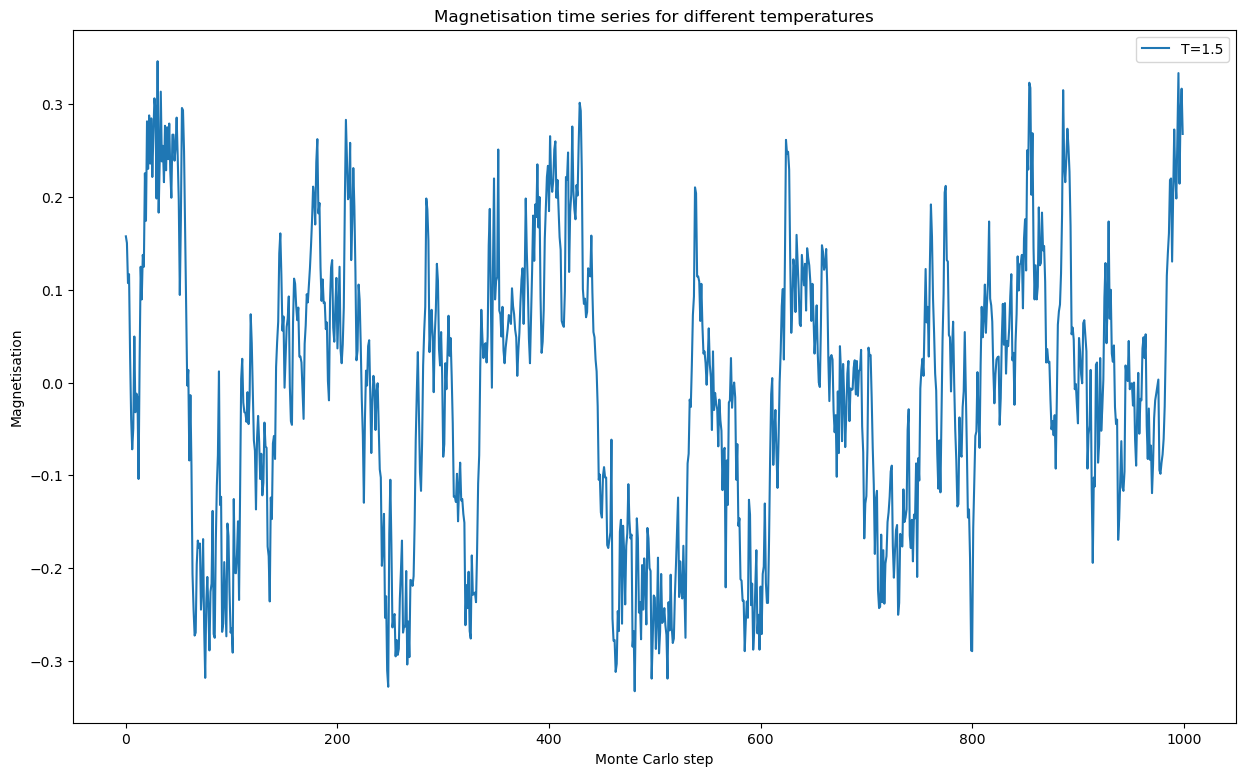

In [6]:
#PLOT MAGNETISATION (MARKET SENTIMENT) AT DIFFERENT TEMPERATURES 

plot_t = [1.5]


def plot_amount(arr,num=100):
    size = arr.size
    if size >= 100:
        sampled_val = int(size/num)
    else:
        sampled_val = 1

    return sampled_val 
 

plt.figure(figsize=(15, 9))
for t in plot_t:
    sampled_val = plot_amount(results[t][4]["Magnetisation"],1000)  
    plt.plot(results[t][4]["Magnetisation"][::sampled_val], label=f"T={t}")
plt.xlabel("Monte Carlo step")
plt.ylabel("Magnetisation")
plt.title("Magnetisation time series for different temperatures")
plt.legend()
plt.show()


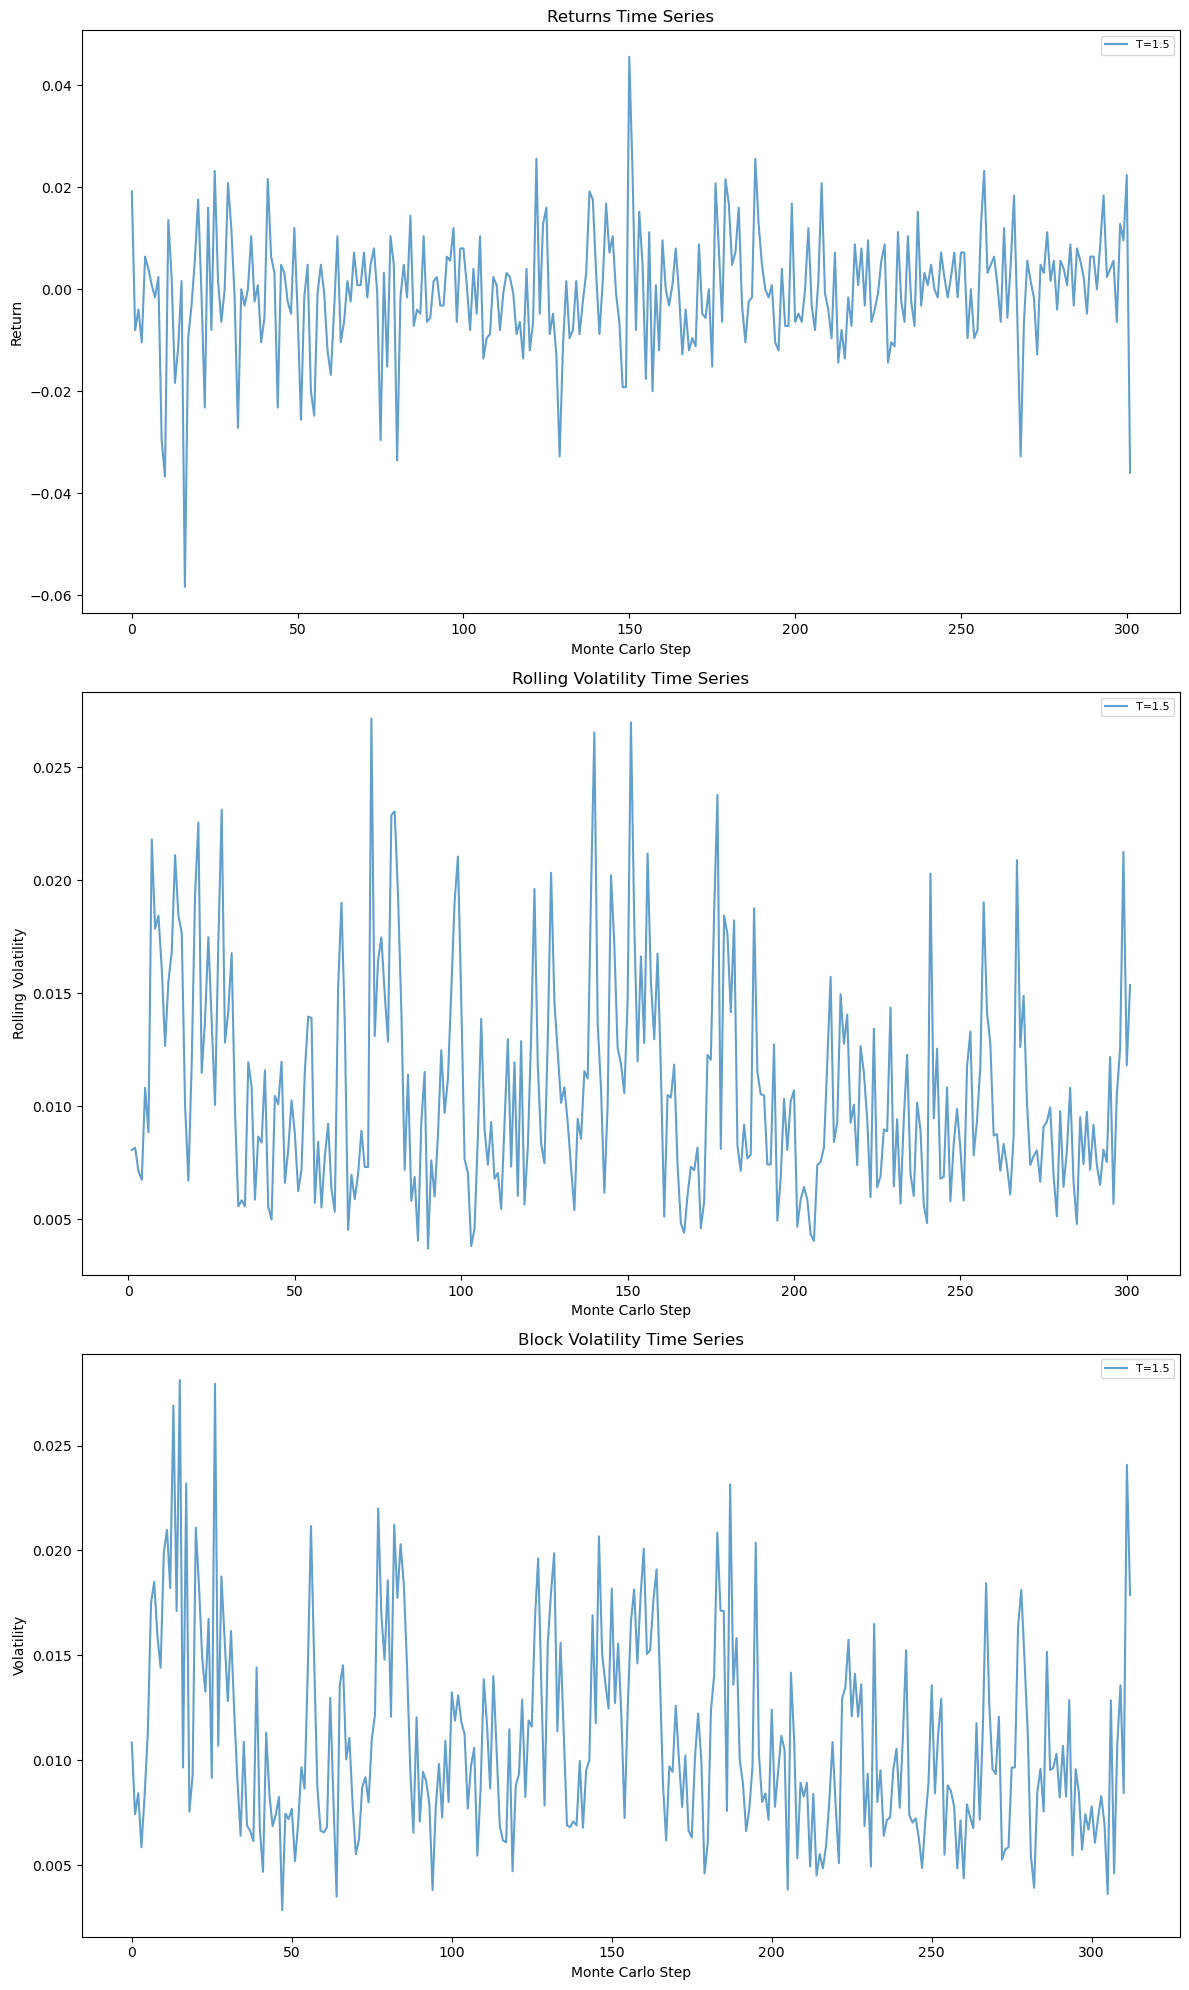

In [7]:

#EXTRACT VALUES INTO LISTS FOR PLOTTING 

average_mag = []
abs_average_mag = []
susceptibility = []
average_energy = []
specific_heat = []
first_returns = []
abs_first_return = []
binder_cumulant = []


#for t in temps:
    #average_mag.append(results[t]["Average_Mag"])
    #abs_average_mag.append(results[t]["Abs_Average_Mag"])
    #susceptibility.append(results[t]["Susceptibility"])
    #average_energy.append(np.mean(results[t]["Energies"]).item())
    #specific_heat.append(results[t]["Heat_Capacity"])
    #binder_cumulant.append(results[t]["Binder_Cumulant"])
    

#PLOT DIFFERENT METRICS 
"""
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

# 1. Mean Magnetisation
axes[0].plot(temps, average_mag, marker="o")
axes[0].set_title("Mean Magnetisation")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel(r"$\langle M \rangle$")

# 2. Mean Absolute Magnetisation
axes[1].plot(temps, abs_average_mag, marker="o")
axes[1].set_title("Mean Absolute Magnetisation")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel(r"$\langle |M| \rangle$")

# 3. Susceptibility
axes[2].plot(temps, susceptibility, marker="o")
axes[2].set_title("Susceptibility")
axes[2].set_xlabel("Temperature")
axes[2].set_ylabel(r"$\chi$")

# 4. Mean Energy
#axes[3].plot(temps, average_energy, marker="o")
#axes[3].set_title("Mean Energy")
#axes[3].set_xlabel("Temperature")
#axes[3].set_ylabel(r"$\langle E \rangle$")

# 5. Specific Heat
axes[4].plot(temps, specific_heat, marker="o")
axes[4].set_title("Specific Heat")
axes[4].set_xlabel("Temperature")
axes[4].set_ylabel(r"$C$")

# 6. Empty subplot (turn it off so it doesn't look stupid)
axes[5].plot(temps, binder_cumulant, marker="o")
axes[5].set_title("Binder Cumulant")
axes[5].set_xlabel("Temperature")
axes[5].set_ylabel(r"$C$")

plt.tight_layout()
plt.show()
"""


fig, axes = plt.subplots(3, 1, figsize=(12, 20))

# Left: Returns
sampled_val = plot_amount(results[t][4]["First_Return"],300)  
for t in plot_t:
    axes[0].plot(results[t][4]["First_Return"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[0].set_title("Returns Time Series")
axes[0].set_xlabel("Monte Carlo Step")
axes[0].set_ylabel("Return")
axes[0].legend(fontsize=8)

# Right: Rolling Volatility
sampled_val = plot_amount(results[t][4]["Rolling_Vol"],300)  
for t in plot_t:
    axes[1].plot(results[t][4]["Rolling_Vol"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[1].set_title("Rolling Volatility Time Series")
axes[1].set_xlabel("Monte Carlo Step")
axes[1].set_ylabel("Rolling Volatility")
axes[1].legend(fontsize=8)

sampled_val = plot_amount(results[t][4]["Non_Rol_Vol"],300)  
for t in plot_t:
    axes[2].plot(results[t][4]["Non_Rol_Vol"][::sampled_val], alpha=0.7, label=f"T={t}")
axes[2].set_title("Block Volatility Time Series")
axes[2].set_xlabel("Monte Carlo Step")
axes[2].set_ylabel("Volatility")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

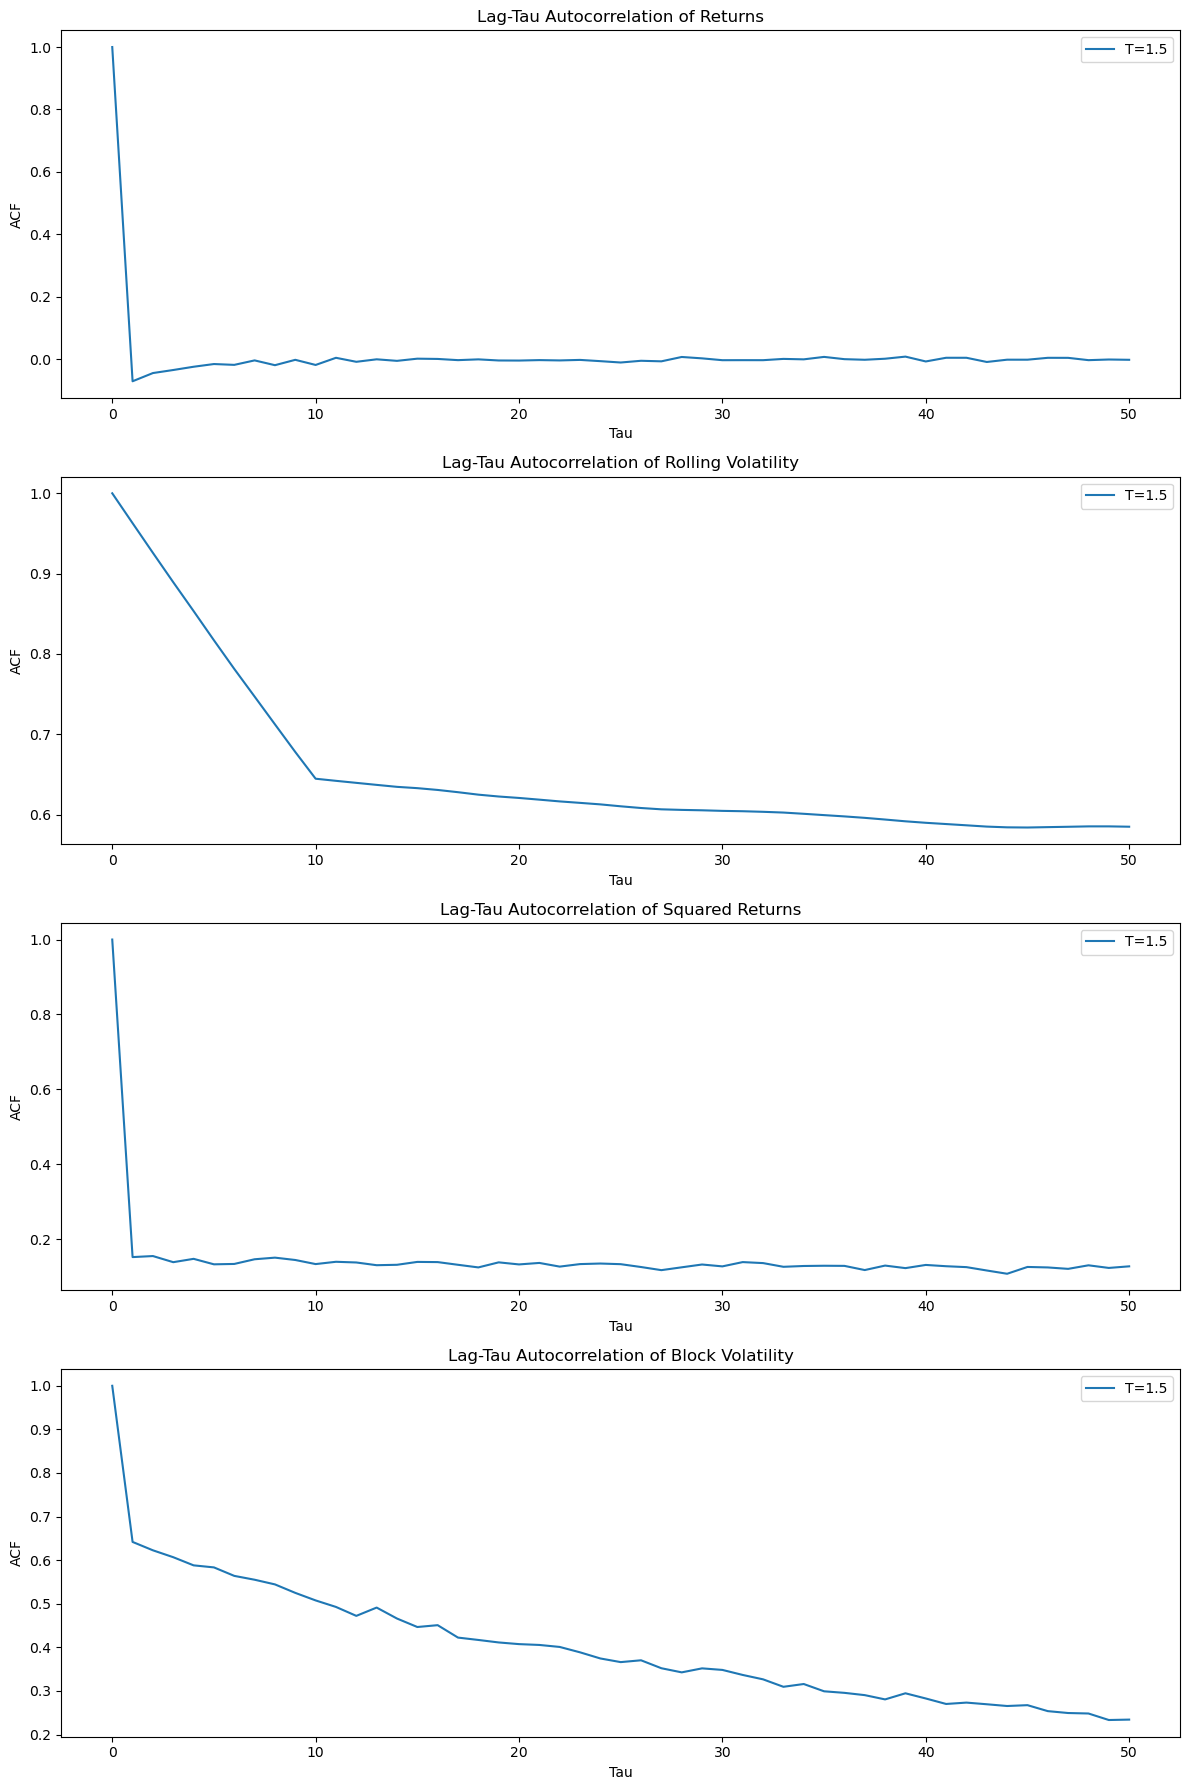

In [9]:
#COMPUTE AND PLOT ACF (mag,returns,abs return), CORRELATION TIME, KURTOSIS


#calculate lag-Tau auto-correlation for Tau up to max_lag




def autocorrelation_function(x, max_lag):
    x = np.asarray(x)
    x = x - np.mean(x)
    N = len(x)
    
    acf = np.zeros(max_lag + 1)
    
    var = np.var(x)
    
    for tau in range(max_lag + 1):
        cov = np.sum(x[:N - tau] * x[tau:]) / (N - tau)
        acf[tau] = cov / var
        
    return acf

acf = {}

for t in temps:
    m = np.array(results[t][4]["Magnetisation"])  # downsample for faster ACF calculation
    r = np.array(results[t][4]["First_Return"])
    abs_r = np.abs(r)
    sq_r = r**2
    rolling_vol_val = np.array(results[t][4]["Rolling_Vol"])
    rolling_vol_val = rolling_vol_val[~np.isnan(rolling_vol_val)] # remove NAN values from rolling vol_val so autocorrelation works 
    block_vol_val = np.array(results[t][4]["Non_Rol_Vol"])


    acf_m = autocorrelation_function(m, 50)
    acf_r = autocorrelation_function(r, 50)
    acf_abs_r = autocorrelation_function(abs_r, 50)
    acf_rolling_vol = autocorrelation_function(rolling_vol_val, 50)
    acf_sq_r = autocorrelation_function(sq_r, 50)
    acf_block_vol = autocorrelation_function(block_vol_val, 50)

    acf[t] = {"acf_m":acf_m,"acf_r":acf_r,"acf_abs_r":acf_abs_r ,"acf_rolling_vol":acf_rolling_vol, "acf_sq_r": acf_sq_r, "acf_block_vol": acf_block_vol }


#Plot AutoCorrelation values for Tau

fig, axes = plt.subplots(4, 1, figsize=(12, 18))
axes = axes.flatten()



for t in plot_t:
    axes[0].plot(acf[t]["acf_r"], label=f"T={t}")
    axes[1].plot(acf[t]["acf_rolling_vol"], label=f"T={t}")
    axes[2].plot(acf[t]["acf_sq_r"], label=f"T={t}")
    axes[3].plot(acf[t]["acf_block_vol"], label=f"T={t}")


axes[0].set_xlabel("Tau")
axes[0].set_ylabel("ACF")
axes[0].set_title("Lag-Tau Autocorrelation of Returns")
axes[0].legend()

axes[1].set_xlabel("Tau")
axes[1].set_ylabel("ACF")
axes[1].set_title("Lag-Tau Autocorrelation of Rolling Volatility")
axes[1].legend()

axes[2].set_xlabel("Tau")
axes[2].set_ylabel("ACF")
axes[2].set_title("Lag-Tau Autocorrelation of Squared Returns")
axes[2].legend()

axes[3].set_xlabel("Tau")
axes[3].set_ylabel("ACF")
axes[3].set_title("Lag-Tau Autocorrelation of Block Volatility")
axes[3].legend()

plt.tight_layout()
plt.show()



In [18]:
summary_rows = []

for T, data in results.items():
    summary_rows.append({
        "Temperature": T,
        "Avg_Mag": data["Average_Mag"],
        "Abs_Avg_Mag": data["Abs_Average_Mag"],
        "Susceptibility": data["Susceptibility"],
        "Heat_Capacity": data["Heat_Capacity"],
        "Binder_Cumulant": data["Binder_Cumulant"]
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("Temperature").reset_index(drop=True)


timeseries_rows = []

for T, data in results.items():
    n = len(data["Magnetisation"])
    
    for i in range(n):
        timeseries_rows.append({
            "Temperature": T,
            "Step": i,
            "Magnetisation": data["Magnetisation"][i],
            "Energy": data["Energies"][i],
            "Return": data["First_Return"][i] if i < len(data["First_Return"]) else None,
            "Rolling_Vol": data["Rolling_Vol"][i] if i < len(data["Rolling_Vol"]) else None
        })

timeseries_df = pd.DataFrame(timeseries_rows)

summary_df.to_csv("ising_summary.csv", index=False)
timeseries_df.to_csv("ising_timeseries.csv", index=False)

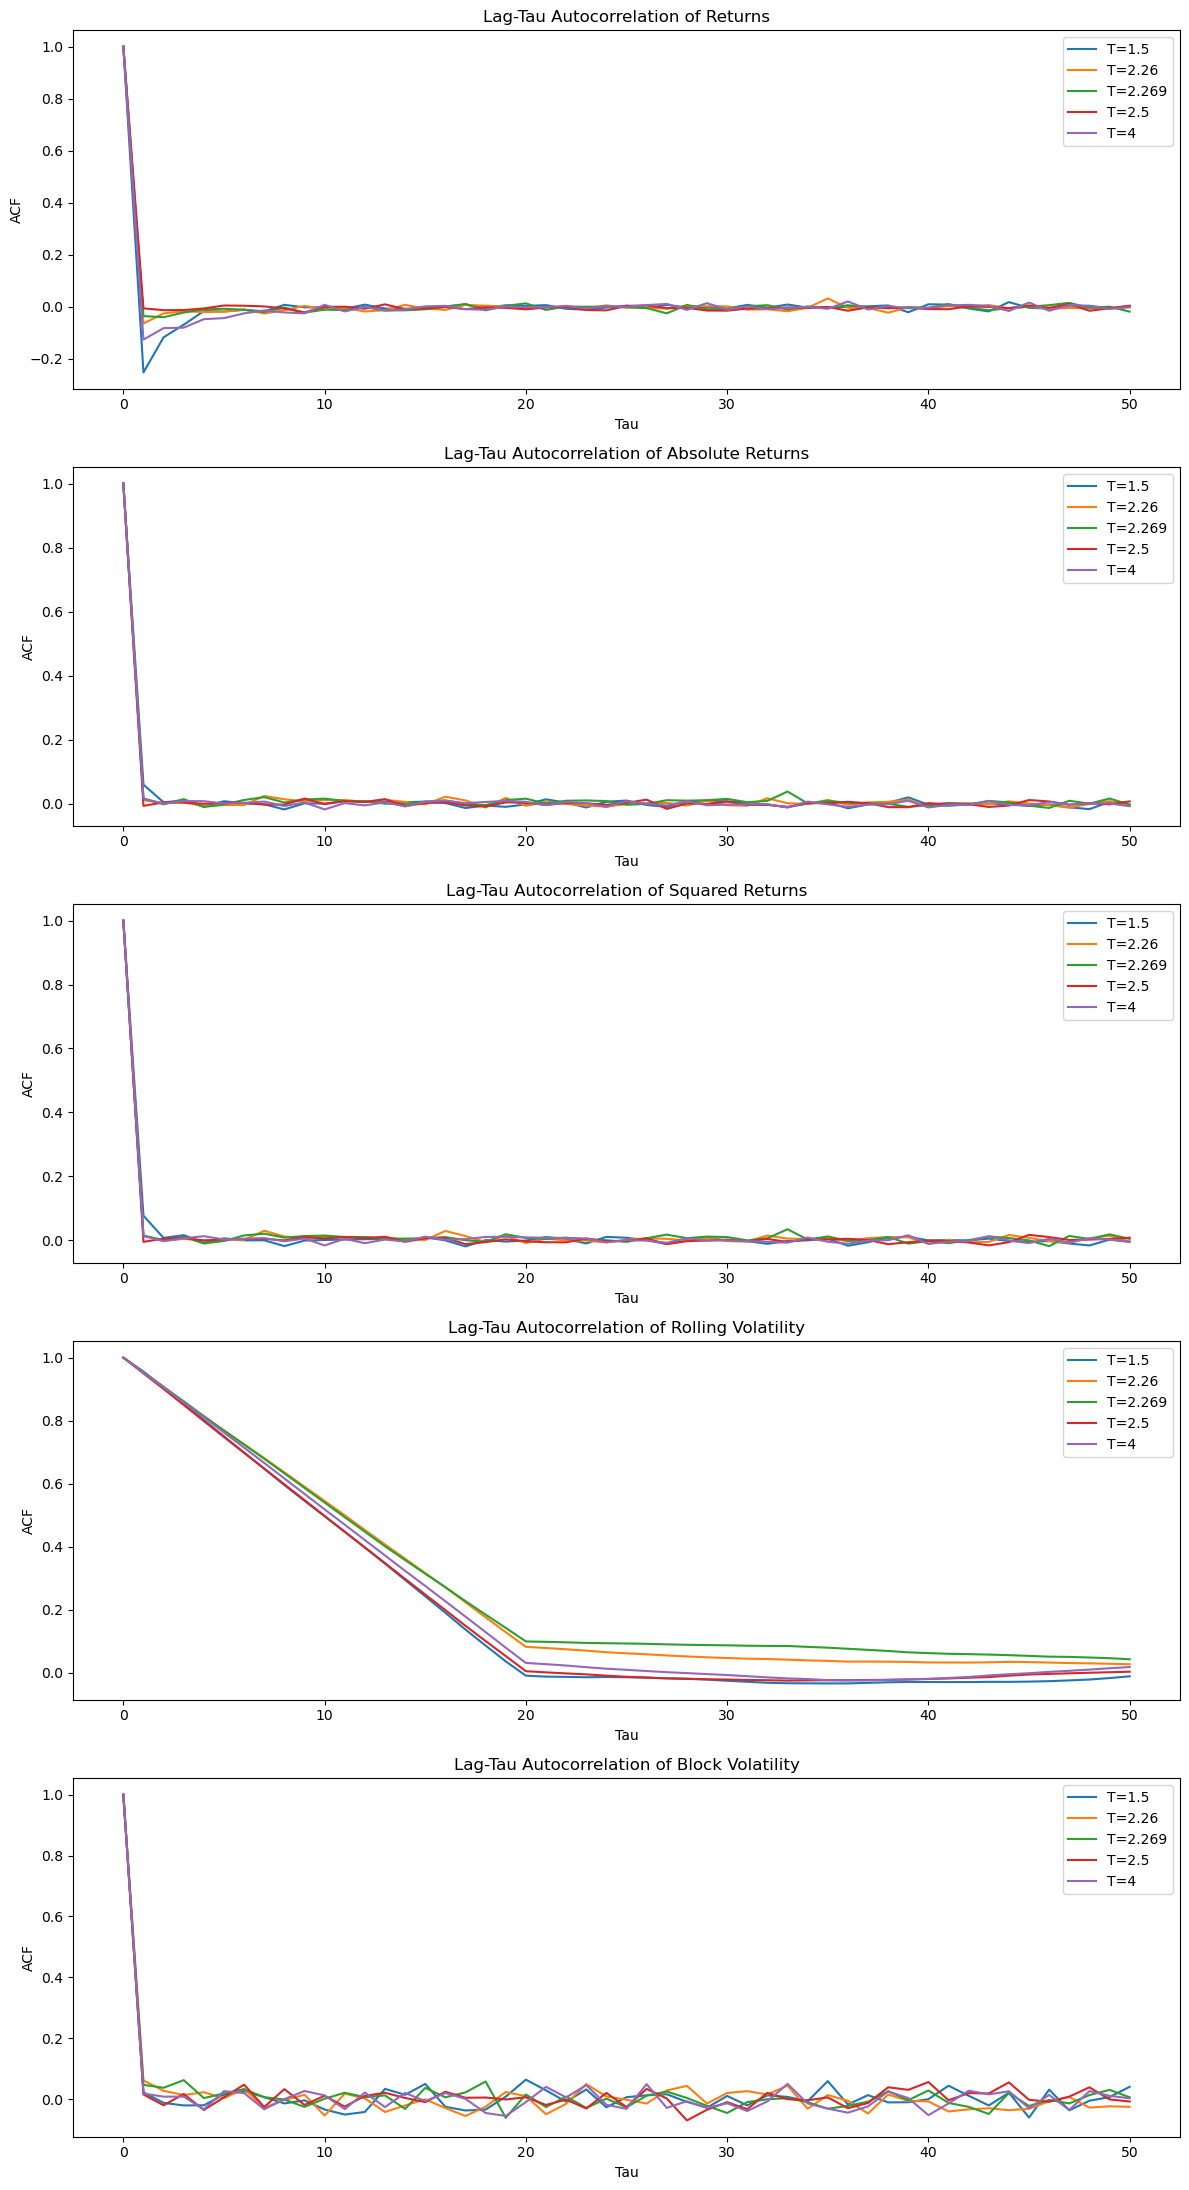

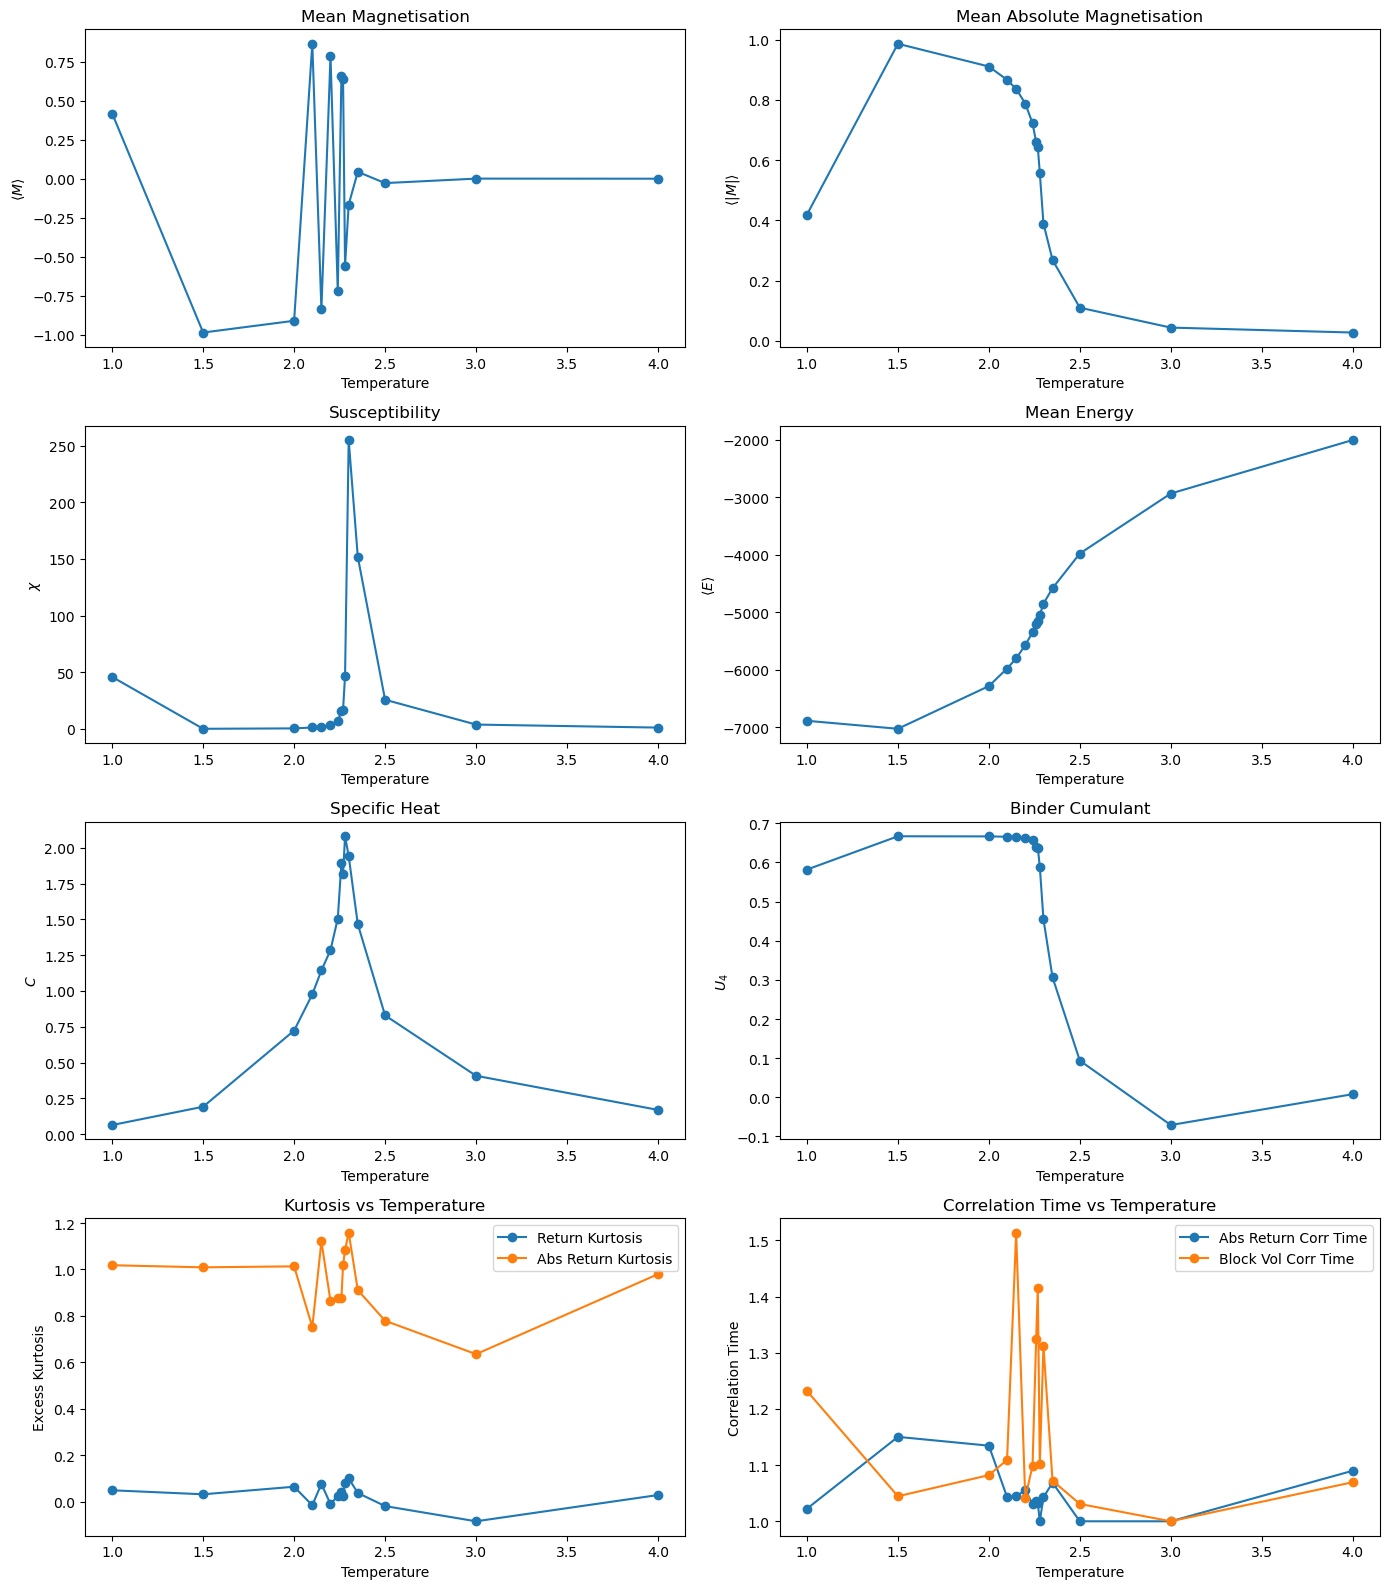

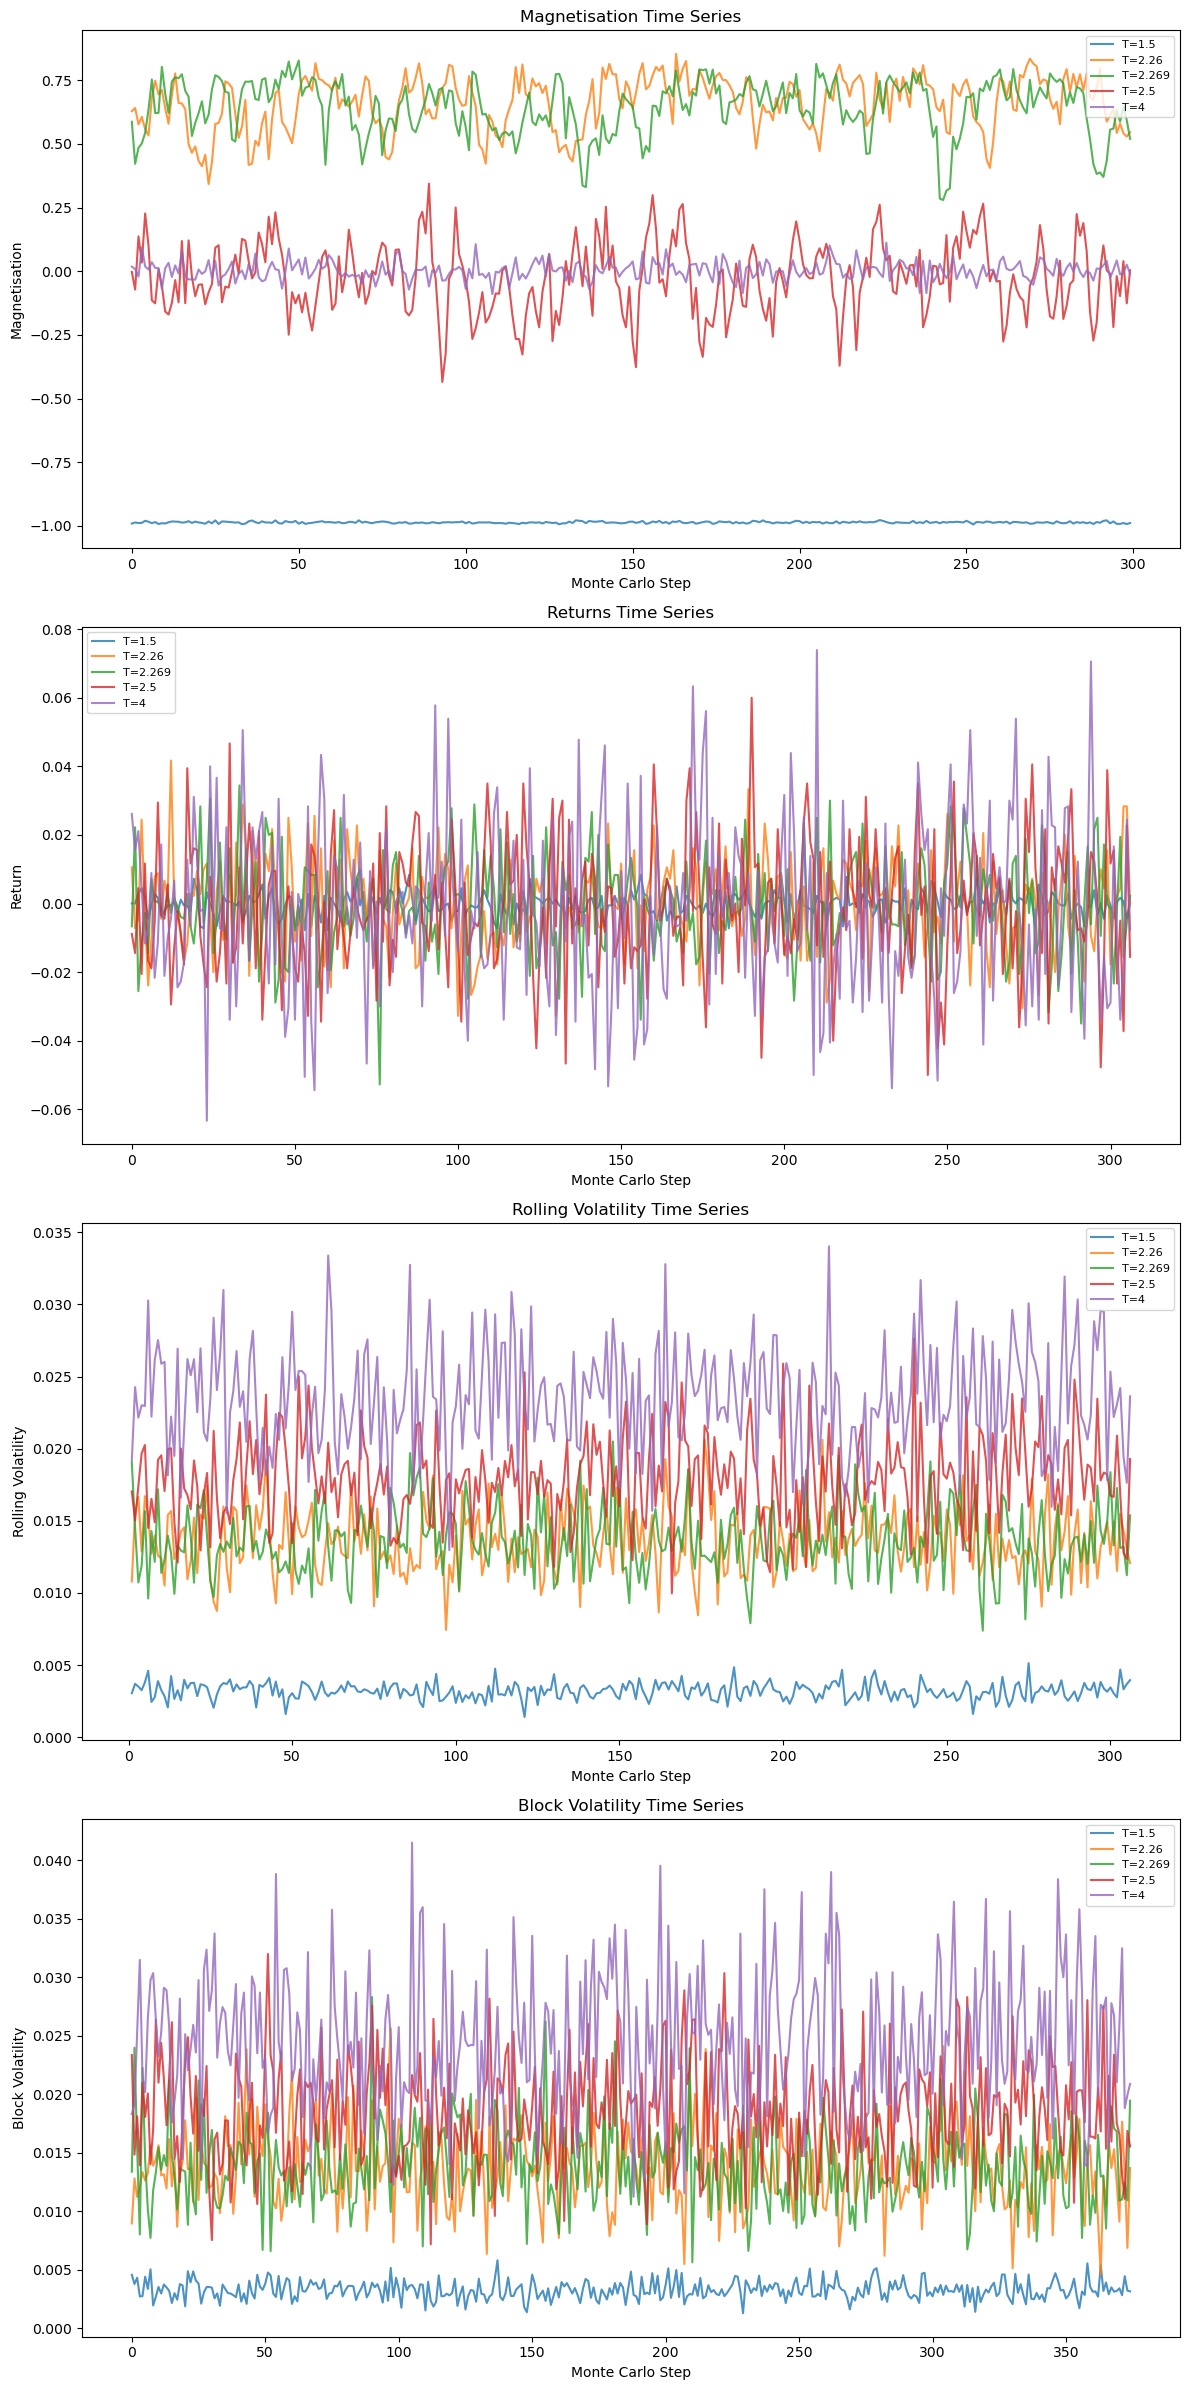

Files overwritten successfully:
 - ising_summary.csv
 - ising_timeseries.csv
 - ising_acf.csv


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#ALL CODE SET TO RUN IN ONE CELL FOR EASE OF EXPORTING TO CSV AND PLOTTING IN OTHER NOTEBOOKS

# =========================================================
# HELPERS
# =========================================================


def autocorrelation_function(x, max_lag):
    x = np.asarray(x)
    x = x - np.mean(x)
    N = len(x)
    
    acf = np.zeros(max_lag + 1)
    
    var = np.var(x)
    
    for tau in range(max_lag + 1):
        cov = np.sum(x[:N - tau] * x[tau:]) / (N - tau)
        acf[tau] = cov / var
        
    return acf


def excess_kurtosis(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]

    if len(x) < 4:
        return np.nan

    mu = np.mean(x)
    sigma = np.std(x)

    if sigma == 0:
        return np.nan

    kurt = np.mean((x - mu)**4) / (sigma**4)
    return kurt - 3.0


def estimate_corr_time(acf_vals):
    acf_vals = np.asarray(acf_vals, dtype=float)
    acf_vals = acf_vals[~np.isnan(acf_vals)]

    if len(acf_vals) < 2:
        return np.nan

    tau_int = 1.0
    for tau in range(1, len(acf_vals)):
        if acf_vals[tau] <= 0:
            break
        tau_int += 2 * acf_vals[tau]

    return tau_int


def safe_slice_for_plot(arr, max_points=300):
    arr = np.asarray(arr)
    n = len(arr)
    if n == 0:
        return arr
    step = max(1, n // max_points)
    return arr[::step]


# =========================================================
# COMPUTE ACF + EXTRA METRICS AND STORE BACK INTO results
# =========================================================

max_lag = 50
acf = {}

for t in temps:
    m = np.asarray(results[t]["Magnetisation"], dtype=float)
    e = np.asarray(results[t]["Energies"], dtype=float)
    r = np.asarray(results[t]["First_Return"], dtype=float)

    abs_r = np.abs(r)
    sq_r = r**2

    rolling_vol_val = np.asarray(results[t]["Rolling_Vol"], dtype=float)
    rolling_vol_val = rolling_vol_val[~np.isnan(rolling_vol_val)]

    block_vol_val = np.asarray(results[t]["Non_Rol_Vol"], dtype=float)
    block_vol_val = block_vol_val[~np.isnan(block_vol_val)]

    lag_m = min(max_lag, max(0, len(m) - 1))
    lag_r = min(max_lag, max(0, len(r) - 1))
    lag_roll = min(max_lag, max(0, len(rolling_vol_val) - 1))
    lag_block = min(max_lag, max(0, len(block_vol_val) - 1))

    acf_m = autocorrelation_function(m, lag_m)
    acf_r = autocorrelation_function(r, lag_r)
    acf_abs_r = autocorrelation_function(abs_r, lag_r)
    acf_sq_r = autocorrelation_function(sq_r, lag_r)
    acf_rolling_vol = autocorrelation_function(rolling_vol_val, lag_roll)
    acf_block_vol = autocorrelation_function(block_vol_val, lag_block)

    acf[t] = {
        "acf_m": acf_m,
        "acf_r": acf_r,
        "acf_abs_r": acf_abs_r,
        "acf_sq_r": acf_sq_r,
        "acf_rolling_vol": acf_rolling_vol,
        "acf_block_vol": acf_block_vol
    }

    # store back into results so export works cleanly
    results[t]["ACF_Mag"] = acf_m
    results[t]["ACF_Return"] = acf_r
    results[t]["ACF_Abs_Return"] = acf_abs_r
    results[t]["ACF_Sq_Return"] = acf_sq_r
    results[t]["ACF_Rolling_Vol"] = acf_rolling_vol
    results[t]["ACF_Block_Vol"] = acf_block_vol

    results[t]["Return_Mean"] = np.mean(r) if len(r) else np.nan
    results[t]["Return_Std"] = np.std(r) if len(r) else np.nan
    results[t]["Abs_Return_Mean"] = np.mean(abs_r) if len(abs_r) else np.nan
    results[t]["Squared_Return_Mean"] = np.mean(sq_r) if len(sq_r) else np.nan
    results[t]["Return_Kurtosis"] = excess_kurtosis(r)
    results[t]["Abs_Return_Kurtosis"] = excess_kurtosis(abs_r)

    results[t]["Rolling_Vol_Mean"] = np.mean(rolling_vol_val) if len(rolling_vol_val) else np.nan
    results[t]["Rolling_Vol_Std"] = np.std(rolling_vol_val) if len(rolling_vol_val) else np.nan
    results[t]["Block_Vol_Mean"] = np.mean(block_vol_val) if len(block_vol_val) else np.nan
    results[t]["Block_Vol_Std"] = np.std(block_vol_val) if len(block_vol_val) else np.nan

    results[t]["Corr_Time_Mag"] = estimate_corr_time(acf_m)
    results[t]["Corr_Time_Return"] = estimate_corr_time(acf_r)
    results[t]["Corr_Time_Abs_Return"] = estimate_corr_time(acf_abs_r)
    results[t]["Corr_Time_Sq_Return"] = estimate_corr_time(acf_sq_r)
    results[t]["Corr_Time_Rolling_Vol"] = estimate_corr_time(acf_rolling_vol)
    results[t]["Corr_Time_Block_Vol"] = estimate_corr_time(acf_block_vol)

    results[t]["ACF1_Return"] = acf_r[1] if len(acf_r) > 1 else np.nan
    results[t]["ACF1_Abs_Return"] = acf_abs_r[1] if len(acf_abs_r) > 1 else np.nan
    results[t]["ACF1_Sq_Return"] = acf_sq_r[1] if len(acf_sq_r) > 1 else np.nan
    results[t]["ACF1_Rolling_Vol"] = acf_rolling_vol[1] if len(acf_rolling_vol) > 1 else np.nan
    results[t]["ACF1_Block_Vol"] = acf_block_vol[1] if len(acf_block_vol) > 1 else np.nan


# =========================================================
# PLOT ACFs
# =========================================================

fig, axes = plt.subplots(5, 1, figsize=(12, 22))

for t in plot_t:
    axes[0].plot(acf[t]["acf_r"], label=f"T={t}")
    axes[1].plot(acf[t]["acf_abs_r"], label=f"T={t}")
    axes[2].plot(acf[t]["acf_sq_r"], label=f"T={t}")
    axes[3].plot(acf[t]["acf_rolling_vol"], label=f"T={t}")
    axes[4].plot(acf[t]["acf_block_vol"], label=f"T={t}")

axes[0].set_title("Lag-Tau Autocorrelation of Returns")
axes[1].set_title("Lag-Tau Autocorrelation of Absolute Returns")
axes[2].set_title("Lag-Tau Autocorrelation of Squared Returns")
axes[3].set_title("Lag-Tau Autocorrelation of Rolling Volatility")
axes[4].set_title("Lag-Tau Autocorrelation of Block Volatility")

for ax in axes:
    ax.set_xlabel("Tau")
    ax.set_ylabel("ACF")
    ax.legend()

plt.tight_layout()
plt.show()


# =========================================================
# EXTRACT SUMMARY VALUES FOR TEMPERATURE PLOTS
# =========================================================

average_mag = []
abs_average_mag = []
susceptibility = []
average_energy = []
specific_heat = []
binder_cumulant = []
return_kurtosis = []
abs_return_kurtosis = []
corr_time_abs_return = []
corr_time_block_vol = []

for t in temps:
    average_mag.append(results[t]["Average_Mag"])
    abs_average_mag.append(results[t]["Abs_Average_Mag"])
    susceptibility.append(results[t]["Susceptibility"])
    average_energy.append(np.mean(results[t]["Energies"]).item())
    specific_heat.append(results[t]["Heat_Capacity"])
    binder_cumulant.append(results[t]["Binder_Cumulant"])
    return_kurtosis.append(results[t]["Return_Kurtosis"])
    abs_return_kurtosis.append(results[t]["Abs_Return_Kurtosis"])
    corr_time_abs_return.append(results[t]["Corr_Time_Abs_Return"])
    corr_time_block_vol.append(results[t]["Corr_Time_Block_Vol"])


# =========================================================
# PLOT THERMODYNAMIC + EXTRA METRICS
# =========================================================

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

axes[0].plot(temps, average_mag, marker="o")
axes[0].set_title("Mean Magnetisation")
axes[0].set_xlabel("Temperature")
axes[0].set_ylabel(r"$\langle M \rangle$")

axes[1].plot(temps, abs_average_mag, marker="o")
axes[1].set_title("Mean Absolute Magnetisation")
axes[1].set_xlabel("Temperature")
axes[1].set_ylabel(r"$\langle |M| \rangle$")

axes[2].plot(temps, susceptibility, marker="o")
axes[2].set_title("Susceptibility")
axes[2].set_xlabel("Temperature")
axes[2].set_ylabel(r"$\chi$")

axes[3].plot(temps, average_energy, marker="o")
axes[3].set_title("Mean Energy")
axes[3].set_xlabel("Temperature")
axes[3].set_ylabel(r"$\langle E \rangle$")

axes[4].plot(temps, specific_heat, marker="o")
axes[4].set_title("Specific Heat")
axes[4].set_xlabel("Temperature")
axes[4].set_ylabel(r"$C$")

axes[5].plot(temps, binder_cumulant, marker="o")
axes[5].set_title("Binder Cumulant")
axes[5].set_xlabel("Temperature")
axes[5].set_ylabel(r"$U_4$")

axes[6].plot(temps, return_kurtosis, marker="o", label="Return Kurtosis")
axes[6].plot(temps, abs_return_kurtosis, marker="o", label="Abs Return Kurtosis")
axes[6].set_title("Kurtosis vs Temperature")
axes[6].set_xlabel("Temperature")
axes[6].set_ylabel("Excess Kurtosis")
axes[6].legend()

axes[7].plot(temps, corr_time_abs_return, marker="o", label="Abs Return Corr Time")
axes[7].plot(temps, corr_time_block_vol, marker="o", label="Block Vol Corr Time")
axes[7].set_title("Correlation Time vs Temperature")
axes[7].set_xlabel("Temperature")
axes[7].set_ylabel("Correlation Time")
axes[7].legend()

plt.tight_layout()
plt.show()


# =========================================================
# PLOT TIME SERIES
# =========================================================

fig, axes = plt.subplots(4, 1, figsize=(12, 24))

for t in plot_t:
    axes[0].plot(safe_slice_for_plot(results[t]["Magnetisation"], 300), alpha=0.8, label=f"T={t}")
axes[0].set_title("Magnetisation Time Series")
axes[0].set_xlabel("Monte Carlo Step")
axes[0].set_ylabel("Magnetisation")
axes[0].legend(fontsize=8)

for t in plot_t:
    axes[1].plot(safe_slice_for_plot(results[t]["First_Return"], 300), alpha=0.8, label=f"T={t}")
axes[1].set_title("Returns Time Series")
axes[1].set_xlabel("Monte Carlo Step")
axes[1].set_ylabel("Return")
axes[1].legend(fontsize=8)

for t in plot_t:
    axes[2].plot(safe_slice_for_plot(results[t]["Rolling_Vol"], 300), alpha=0.8, label=f"T={t}")
axes[2].set_title("Rolling Volatility Time Series")
axes[2].set_xlabel("Monte Carlo Step")
axes[2].set_ylabel("Rolling Volatility")
axes[2].legend(fontsize=8)

for t in plot_t:
    axes[3].plot(safe_slice_for_plot(results[t]["Non_Rol_Vol"], 300), alpha=0.8, label=f"T={t}")
axes[3].set_title("Block Volatility Time Series")
axes[3].set_xlabel("Monte Carlo Step")
axes[3].set_ylabel("Block Volatility")
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# EXPORT CSVs - OVERWRITES EXISTING FILES
# =========================================================

summary_rows = []

for T, data in results.items():
    summary_rows.append({
        "Temperature": T,
        "Avg_Mag": data.get("Average_Mag", np.nan),
        "Abs_Avg_Mag": data.get("Abs_Average_Mag", np.nan),
        "Avg_Energy": np.mean(data["Energies"]) if "Energies" in data else np.nan,
        "Susceptibility": data.get("Susceptibility", np.nan),
        "Heat_Capacity": data.get("Heat_Capacity", np.nan),
        "Binder_Cumulant": data.get("Binder_Cumulant", np.nan),

        "Return_Mean": data.get("Return_Mean", np.nan),
        "Return_Std": data.get("Return_Std", np.nan),
        "Abs_Return_Mean": data.get("Abs_Return_Mean", np.nan),
        "Squared_Return_Mean": data.get("Squared_Return_Mean", np.nan),
        "Return_Kurtosis": data.get("Return_Kurtosis", np.nan),
        "Abs_Return_Kurtosis": data.get("Abs_Return_Kurtosis", np.nan),

        "Rolling_Vol_Mean": data.get("Rolling_Vol_Mean", np.nan),
        "Rolling_Vol_Std": data.get("Rolling_Vol_Std", np.nan),
        "Block_Vol_Mean": data.get("Block_Vol_Mean", np.nan),
        "Block_Vol_Std": data.get("Block_Vol_Std", np.nan),

        "Corr_Time_Mag": data.get("Corr_Time_Mag", np.nan),
        "Corr_Time_Return": data.get("Corr_Time_Return", np.nan),
        "Corr_Time_Abs_Return": data.get("Corr_Time_Abs_Return", np.nan),
        "Corr_Time_Sq_Return": data.get("Corr_Time_Sq_Return", np.nan),
        "Corr_Time_Rolling_Vol": data.get("Corr_Time_Rolling_Vol", np.nan),
        "Corr_Time_Block_Vol": data.get("Corr_Time_Block_Vol", np.nan),

        "ACF1_Return": data.get("ACF1_Return", np.nan),
        "ACF1_Abs_Return": data.get("ACF1_Abs_Return", np.nan),
        "ACF1_Sq_Return": data.get("ACF1_Sq_Return", np.nan),
        "ACF1_Rolling_Vol": data.get("ACF1_Rolling_Vol", np.nan),
        "ACF1_Block_Vol": data.get("ACF1_Block_Vol", np.nan),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Temperature").reset_index(drop=True)


timeseries_rows = []

for T, data in results.items():
    mags = np.asarray(data.get("Magnetisation", []), dtype=float)
    energies = np.asarray(data.get("Energies", []), dtype=float)
    returns = np.asarray(data.get("First_Return", []), dtype=float)
    abs_returns = np.abs(returns)
    sq_returns = returns**2
    rolling_vol = np.asarray(data.get("Rolling_Vol", []), dtype=float)
    block_vol = np.asarray(data.get("Non_Rol_Vol", []), dtype=float)

    n = max(len(mags), len(energies), len(returns), len(rolling_vol), len(block_vol))

    for i in range(n):
        timeseries_rows.append({
            "Temperature": T,
            "Step": i,
            "Magnetisation": mags[i] if i < len(mags) else np.nan,
            "Energy": energies[i] if i < len(energies) else np.nan,
            "Return": returns[i] if i < len(returns) else np.nan,
            "Abs_Return": abs_returns[i] if i < len(abs_returns) else np.nan,
            "Squared_Return": sq_returns[i] if i < len(sq_returns) else np.nan,
            "Rolling_Vol": rolling_vol[i] if i < len(rolling_vol) else np.nan,
            "Block_Vol": block_vol[i] if i < len(block_vol) else np.nan,
        })

timeseries_df = pd.DataFrame(timeseries_rows)


acf_rows = []

for T, data in results.items():
    acf_m = np.asarray(data.get("ACF_Mag", []), dtype=float)
    acf_r = np.asarray(data.get("ACF_Return", []), dtype=float)
    acf_abs_r = np.asarray(data.get("ACF_Abs_Return", []), dtype=float)
    acf_sq_r = np.asarray(data.get("ACF_Sq_Return", []), dtype=float)
    acf_roll = np.asarray(data.get("ACF_Rolling_Vol", []), dtype=float)
    acf_block = np.asarray(data.get("ACF_Block_Vol", []), dtype=float)

    n_lags = max(len(acf_m), len(acf_r), len(acf_abs_r), len(acf_sq_r), len(acf_roll), len(acf_block))

    for tau in range(n_lags):
        acf_rows.append({
            "Temperature": T,
            "Lag": tau,
            "ACF_Mag": acf_m[tau] if tau < len(acf_m) else np.nan,
            "ACF_Return": acf_r[tau] if tau < len(acf_r) else np.nan,
            "ACF_Abs_Return": acf_abs_r[tau] if tau < len(acf_abs_r) else np.nan,
            "ACF_Sq_Return": acf_sq_r[tau] if tau < len(acf_sq_r) else np.nan,
            "ACF_Rolling_Vol": acf_roll[tau] if tau < len(acf_roll) else np.nan,
            "ACF_Block_Vol": acf_block[tau] if tau < len(acf_block) else np.nan,
        })

acf_df = pd.DataFrame(acf_rows)

# These overwrite the previous files automatically
summary_df.to_csv("ising_summary.csv", index=False)
timeseries_df.to_csv("ising_timeseries.csv", index=False)
acf_df.to_csv("ising_acf.csv", index=False)

print("Files overwritten successfully:")
print(" - ising_summary.csv")
print(" - ising_timeseries.csv")
print(" - ising_acf.csv")